# EGFR "Virtual Biopsy" — v3.1: attack the data limit (AIM-coordinate recovery)

**The diagnosis from every prior run:** the binding constraint is **~21 positives**, not the architecture.
So v3.1 stops tuning the model and grows the cohort.

**Changes vs v3**
1. **Image branch reverted to `"2.5d"`** — the slice-ViT (727k params) overfit 21 positives and dropped
   fusion to 0.47. The pretrained 2.5D ResNet was the strongest, most stable image branch; we keep it.
2. **AIM-coordinate recovery (the headline).** Patients with no DICOM SEG are no longer dropped: we read
   the radiologist's tumour markup (the `TwoDimensionCircle` x/y + referenced slice) from the AIM XML and
   crop a cube around it. Target: 111 -> ~150-170 patients, ~21 -> ~38 positives. This nearly halves the
   error bars — the only thing that lets us actually rank models.
3. **Repeated CV with fold-wise mean+/-std as the PRIMARY metric.** The pooled out-of-fold AUROC you were
   reading is biased by cross-fold calibration drift (you saw clinical-only show fold-mean 0.718 but pooled
   0.557). Fold-wise AUROC is rank-based and the right statistic; pooled is reported only as a secondary.
4. **Robust AIM parsers + a tag census** so you can see exactly what each site's XML contains.

**Honest expectation:** AIM crops are looser than SEG masks (a 2D circle -> approximate cube), so mean image
quality dips slightly, but doubling positives tightens every confidence interval. Expect a *trustworthy*
measurement, not a jump to 0.9.


## 1. Install dependencies (run once)

In [1]:
import sys
# !{sys.executable} -m pip install -q "pydicom<3" pydicom-seg SimpleITK scipy scikit-learn matplotlib tqdm torchvision
print("done")
# !pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

done


## 2. Imports

In [2]:
import os, glob, shutil, random, warnings, math, numpy as np, pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path
import pydicom, pydicom_seg, SimpleITK as sitk
from scipy import ndimage
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tvm
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, roc_curve
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k): return x
warnings.filterwarnings("ignore")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch", torch.__version__, "| Device:", DEVICE)

Torch 2.12.1+cu126 | Device: cuda


d:\git\PhDProjects\LungCancerGrading\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. CONFIG

In [3]:
# ---------- PATHS (EDIT) ----------
DATA_ROOT    = Path("data/nsclc_radiogenomics")
CLINICAL_CSV = Path("data/NSCLCR01Radiogenomic_DATA_LABELS_2018-05-22_1500-shifted.csv")
AIM_DIR      = Path("data/AIM_files_updated-11-10-2020/AIM_files_updated-11-10-2020")
CACHE_BASE   = Path("egfr_cache")
OUTPUT_DIR   = Path("egfr_out"); OUTPUT_DIR.mkdir(exist_ok=True)

# ---------- TARGET ----------
TARGET_COL, POS_LABEL, NEG_LABEL = "EGFR mutation status", "Mutant", "Wildtype"

# ---------- IMAGE PREPROCESSING ----------
TARGET_SHAPE   = (32, 64, 64)     # (D,H,W)
CROP_PAD_VOX   = 16
HU_MIN, HU_MAX = -1000, 400
REQUIRE_SEG    = False            # v3.1: do NOT require SEG; fall back to AIM coordinates
USE_AIM_COORD_FALLBACK = True     # <<< the recovery: crop no-SEG patients from AIM markup
ALLOW_CENTER_CROP_FALLBACK = False
AIM_DEPTH_SLICES = TARGET_SHAPE[0]   # +/- half of this around the annotated slice
FORCE_REBUILD  = False            # cache tag below changes when AIM is toggled, so it rebuilds cleanly

# ---------- TABULAR ----------
INCLUDE_HISTOLOGY = False
INCLUDE_ETHNICITY = True

# ---------- MODEL ----------
IMAGE_BACKBONE = "3d"           # reverted from "vit_slices". Options: "2.5d" | "3d" | "vit_slices"
PRETRAINED     = True
IMG_FEAT_DIM   = 64
TAB_HIDDEN     = 64
FUSION_HIDDEN  = 64
DROPOUT        = 0.4
# slice-ViT knobs (only used if IMAGE_BACKBONE=="vit_slices")
FREEZE_SLICE_BACKBONE = True; VIT_D_MODEL=192; VIT_HEADS=3; VIT_LAYERS=2; VIT_FF=384; SLICE_RES=224

# ---------- TRAINING ----------
N_FOLDS = 5
N_REPEATS = 5                     # repeated CV -> trustworthy fold-mean +/- std (this is the point)
EPOCHS  = 60
LR      = 1e-4
WEIGHT_DECAY = 1e-4
BATCH_SIZE   = 8
USE_AUGMENTATION  = True
USE_CLASS_WEIGHTS = True
SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

PRE_TAG = f"seg{int(REQUIRE_SEG)}_aim{int(USE_AIM_COORD_FALLBACK)}_{TARGET_SHAPE[0]}x{TARGET_SHAPE[1]}x{TARGET_SHAPE[2]}_pad{CROP_PAD_VOX}"
CACHE_DIR = CACHE_BASE / PRE_TAG
if FORCE_REBUILD and CACHE_DIR.exists(): shutil.rmtree(CACHE_DIR)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
print("cache:", CACHE_DIR)

cache: egfr_cache\seg0_aim1_32x64x64_pad16


## 4. Clinical labels + tabular features

In [4]:
clin = pd.read_csv(CLINICAL_CSV)
clin["Case ID"] = clin["Case ID"].astype(str).str.strip()
clin["label"] = clin[TARGET_COL].map({POS_LABEL: 1, NEG_LABEL: 0})
clin = clin.dropna(subset=["label"]).copy(); clin["label"] = clin["label"].astype(int)
print("Usable EGFR labels:", len(clin)); print(clin["label"].value_counts().rename({0:NEG_LABEL,1:POS_LABEL}))

def build_tabular(df):
    f = pd.DataFrame(index=df.index)
    age = pd.to_numeric(df["Age at Histological Diagnosis"], errors="coerce")
    f["age"] = age.fillna(age.median())/100.0
    f["male"] = (df["Gender"].astype(str).str.strip().str.lower()=="male").astype(float)
    sm = df["Smoking status"].astype(str).str.strip()
    for v in ["Nonsmoker","Former","Current"]: f[f"smk_{v}"] = (sm==v).astype(float)
    for c in [c for c in df.columns if c.startswith("Tumor Location")]:
        key = c.split("choice=")[-1].rstrip(")").strip().replace(" ","_")
        f[f"loc_{key}"] = (df[c].astype(str).str.strip().str.lower()=="checked").astype(float)
    f = pd.concat([f, pd.get_dummies(df["%GG"].astype(str).str.strip(), prefix="gg").astype(float)], axis=1)
    if INCLUDE_ETHNICITY and "Ethnicity" in df.columns:
        f = pd.concat([f, pd.get_dummies(df["Ethnicity"].astype(str).str.strip(), prefix="eth").astype(float)], axis=1)
    if INCLUDE_HISTOLOGY:
        f = pd.concat([f, pd.get_dummies(df["Histology "].astype(str).str.strip(), prefix="hist").astype(float)], axis=1)
    return f

print("Tabular features:", build_tabular(clin).shape[1])

Usable EGFR labels: 172
label
Wildtype    129
Mutant       43
Name: count, dtype: int64
Tabular features: 25


## 5. Index DICOM (CT + SEG) and match each patient to an AIM file

In [5]:
ALL_AIM = glob.glob(os.path.join(str(AIM_DIR), "*.xml")) if AIM_DIR.exists() else []
def aim_file_for(cid):
    mf = [f for f in ALL_AIM if cid in os.path.basename(f)]
    return mf[0] if mf else None

def scan_patient(pdir):
    info = {"ct_dir": None, "ct_n": 0, "seg_file": None, "seg_modality": None}
    for root, _, files in os.walk(pdir):
        dcms = [f for f in files if f.lower().endswith(".dcm")]
        if not dcms: continue
        try:
            ds = pydicom.dcmread(os.path.join(root, dcms[0]), stop_before_pixels=True, force=True)
        except Exception: continue
        mod = str(getattr(ds, "Modality", "")).upper()
        if mod == "CT":
            if len(dcms) > info["ct_n"]: info["ct_dir"], info["ct_n"] = root, len(dcms)
        elif mod in ("SEG","RTSTRUCT"):
            info["seg_file"], info["seg_modality"] = os.path.join(root, dcms[0]), mod
    return info

records = []
for cid in tqdm(clin["Case ID"].tolist(), desc="indexing"):
    pdir = DATA_ROOT/cid
    info = scan_patient(pdir) if pdir.exists() else {"ct_dir":None,"ct_n":0,"seg_file":None,"seg_modality":None}
    info["Case ID"] = cid; info["aim_file"] = aim_file_for(cid); records.append(info)
idx = pd.DataFrame(records)
cohort = clin.merge(idx, on="Case ID", how="left")
print("CT:", cohort["ct_dir"].notna().sum(), "| SEG:", (cohort["seg_modality"]=="SEG").sum(),
      "| AIM file:", cohort["aim_file"].notna().sum(), "| no SEG:", (cohort["seg_modality"]!="SEG").sum())

indexing: 100%|██████████| 172/172 [00:14<00:00, 11.72it/s]


CT: 172 | SEG: 117 | AIM file: 158 | no SEG: 55


## 6. AIM markup parser + coordinate cropper

The AIM `MarkupEntity` (a `TwoDimensionCircle`) gives the tumour centre as pixel x/y on a specific CT slice,
identified by its SOP Instance UID. We map that UID to the slice index in the loaded volume, estimate the
radius from the two stored points, and crop a cube. This is the geometry that lets us recover no-SEG patients.

In [6]:
def _local(t): return t.rsplit('}',1)[-1]

def parse_aim_markup(xml_path):
    """-> list of {sop, frame, xy:[(x,y),...]} for each markup entity."""
    out = []
    try: root = ET.parse(xml_path).getroot()
    except Exception: return out
    for me in root.iter():
        if _local(me.tag) != "MarkupEntity": continue
        sop=None; frame=None; pts=[]
        for el in me.iter():
            lt=_local(el.tag)
            if lt=="imageReferenceUid": sop = el.get("root")
            elif lt=="referencedFrameNumber": frame = el.get("value")
            elif lt=="TwoDimensionSpatialCoordinate":
                x=y=None
                for c in el:
                    if _local(c.tag)=="x": x=float(c.get("value"))
                    if _local(c.tag)=="y": y=float(c.get("value"))
                if x is not None and y is not None: pts.append((x,y))
        if pts: out.append({"sop":sop, "frame":frame, "xy":pts})
    return out

def sop_to_zindex(ct_dir):
    """Map SOPInstanceUID -> z index (GDCM file order == SimpleITK array z order)."""
    files = sitk.ImageSeriesReader().GetGDCMSeriesFileNames(str(ct_dir))
    m = {}
    for i, fp in enumerate(files):
        try:
            ds = pydicom.dcmread(fp, stop_before_pixels=True, force=True)
            m[str(getattr(ds,'SOPInstanceUID',''))] = i
        except Exception: pass
    return m

def _finish_cube(crop):
    if crop.size == 0 or min(crop.shape) < 2: return None
    crop = ndimage.zoom(crop.astype(np.float32), [t/max(1,s) for t,s in zip(TARGET_SHAPE,crop.shape)], order=1)
    crop = np.clip(crop, HU_MIN, HU_MAX)
    return ((crop-HU_MIN)/(HU_MAX-HU_MIN)).astype(np.float32)

def crop_from_aim(ct_arr, sop_map, markups):
    """Crop a cube around the AIM tumour markup. Returns (cube, info) or (None, reason)."""
    Z,Y,X = ct_arr.shape
    for mk in markups:
        if mk["sop"] not in sop_map: continue
        z = sop_map[mk["sop"]]; pts = mk["xy"]
        cx, cy = pts[0]
        r = math.hypot(pts[1][0]-cx, pts[1][1]-cy) if len(pts) >= 2 else 25.0
        r = max(r, 10.0)
        half = int(round(r)) + CROP_PAD_VOX
        dz = AIM_DEPTH_SLICES // 2
        y0,y1 = max(0,int(cy)-half), min(Y,int(cy)+half)
        x0,x1 = max(0,int(cx)-half), min(X,int(cx)+half)
        z0,z1 = max(0,z-dz), min(Z,z+dz)
        cube = _finish_cube(ct_arr[z0:z1, y0:y1, x0:x1])
        if cube is not None:
            return cube, {"z":z, "cx":round(cx,1), "cy":round(cy,1), "r":round(r,1)}
    return None, "no_resolvable_markup"

## 7. Preprocess -> tumour cubes (SEG first, AIM-coordinate fallback)

In [7]:
def load_ct(ct_dir):
    r = sitk.ImageSeriesReader(); r.SetFileNames(r.GetGDCMSeriesFileNames(str(ct_dir))); return r.Execute()

def seg_mask_on_ct(seg_file, ct_img):
    result = pydicom_seg.SegmentReader().read(pydicom.dcmread(seg_file))
    mask = None
    for num in result.available_segments:
        res = sitk.Resample(result.segment_image(num), ct_img, sitk.Transform(), sitk.sitkNearestNeighbor, 0, sitk.sitkUInt8)
        a = sitk.GetArrayFromImage(res).astype(bool)
        mask = a if mask is None else (mask | a)
    return mask

def crop_to_cube(ct_arr, mask):
    if mask is not None and mask.any():
        zz,yy,xx = np.where(mask); p=CROP_PAD_VOX
        z0,z1=max(0,zz.min()-p),min(ct_arr.shape[0],zz.max()+p+1)
        y0,y1=max(0,yy.min()-p),min(ct_arr.shape[1],yy.max()+p+1)
        x0,x1=max(0,xx.min()-p),min(ct_arr.shape[2],xx.max()+p+1)
    else:
        Z,Y,X=ct_arr.shape; z0,z1=int(Z*.25),int(Z*.75);y0,y1=int(Y*.2),int(Y*.8);x0,x1=int(X*.2),int(X*.8)
    return _finish_cube(ct_arr[z0:z1,y0:y1,x0:x1])

status = []
for _, row in tqdm(cohort.iterrows(), total=len(cohort), desc="preprocess"):
    cid = row["Case ID"]; out = CACHE_DIR/f"{cid}.npy"
    if out.exists(): status.append((cid,"cached")); continue
    if pd.isna(row["ct_dir"]): status.append((cid,"no_ct")); continue
    try:
        ct = load_ct(row["ct_dir"]); ct_arr = sitk.GetArrayFromImage(ct)
        # 1) SEG path
        mask = None
        if row["seg_modality"]=="SEG":
            try: mask = seg_mask_on_ct(row["seg_file"], ct)
            except Exception: mask = None
        if mask is not None and mask.any():
            cube = crop_to_cube(ct_arr, mask)
            if cube is not None: np.save(out, cube); status.append((cid,"ok_seg")); continue
        # 2) AIM-coordinate recovery
        if USE_AIM_COORD_FALLBACK and isinstance(row["aim_file"], str):
            markups = parse_aim_markup(row["aim_file"])
            if markups:
                smap = sop_to_zindex(row["ct_dir"])
                cube, info = crop_from_aim(ct_arr, smap, markups)
                if cube is not None: np.save(out, cube); status.append((cid,"ok_aim")); continue
                status.append((cid,"aim_unresolved")); continue
            status.append((cid,"aim_no_markup")); continue
        # 3) optional center crop
        if ALLOW_CENTER_CROP_FALLBACK and not REQUIRE_SEG:
            cube = crop_to_cube(ct_arr, None)
            if cube is not None: np.save(out, cube); status.append((cid,"ok_centercrop")); continue
        status.append((cid,"no_seg_skipped"))
    except Exception as e:
        status.append((cid, f"error:{type(e).__name__}"))

st = pd.DataFrame(status, columns=["Case ID","status"]); print(st["status"].value_counts())
cohort = cohort.merge(st, on="Case ID", how="left")
cohort = cohort[cohort["status"].isin(["ok_seg","ok_aim","ok_centercrop","cached"])].reset_index(drop=True)
print("\nFinal cohort:", len(cohort))
print(cohort["label"].value_counts().rename({0:NEG_LABEL,1:POS_LABEL}))
print("source mix:", cohort["status"].value_counts().to_dict())

preprocess: 100%|██████████| 172/172 [01:14<00:00,  2.30it/s]

status
cached            139
aim_unresolved     20
no_seg_skipped     13
Name: count, dtype: int64

Final cohort: 139
label
Wildtype    106
Mutant       33
Name: count, dtype: int64
source mix: {'cached': 139}


## 8. SANITY CHECK — eyeball a few AIM-recovered crops

**Do this before trusting the recovery.** If the middle slice of an `ok_aim` cube doesn't show a tumour
roughly centred, the SOP->z mapping or x/y convention is off for that site and needs adjustment.

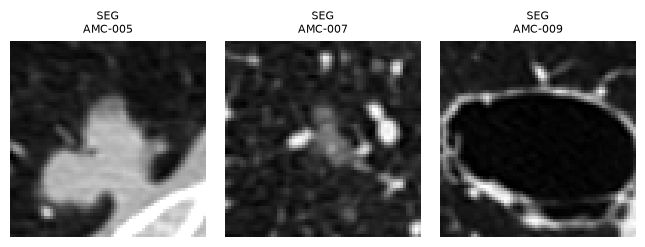

In [8]:
import matplotlib.pyplot as plt
aim_ids = cohort.loc[cohort["status"]=="ok_aim","Case ID"].tolist()[:6]
seg_ids = cohort.loc[cohort["status"].isin(["ok_seg","cached"]),"Case ID"].tolist()[:3]
show = [("AIM",c) for c in aim_ids] + [("SEG",c) for c in seg_ids]
if show:
    n=len(show); fig,ax=plt.subplots(1,n,figsize=(2.2*n,2.4))
    if n==1: ax=[ax]
    for a,(src,cid) in zip(ax,show):
        cube=np.load(CACHE_DIR/f"{cid}.npy"); a.imshow(cube[cube.shape[0]//2],cmap="gray")
        a.set_title(f"{src}\n{cid}",fontsize=8); a.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("No crops to show.")

## 9. Tabular matrix + Dataset

In [9]:
tab_mat = build_tabular(cohort).values.astype(np.float32)
N_TAB = tab_mat.shape[1]; labels = cohort["label"].values.astype(np.float32)
print("Tabular dim:", N_TAB, "| N:", len(cohort), "| positives:", int(labels.sum()))

def augment_cube(cube):
    if random.random()<0.5: cube = torch.flip(cube, dims=[2])
    if random.random()<0.5: cube = torch.flip(cube, dims=[3])
    cube = cube*random.uniform(0.9,1.1) + random.uniform(-0.05,0.05)
    return cube.clamp(0,1)

class EGFRDataset(Dataset):
    def __init__(self, indices, train=False):
        self.indices=list(indices); self.train=train
    def __len__(self): return len(self.indices)
    def __getitem__(self, k):
        i = self.indices[k]
        cube = np.load(CACHE_DIR/f"{cohort.iloc[i]['Case ID']}.npy")
        img = torch.from_numpy(cube).float().unsqueeze(0)
        if self.train and USE_AUGMENTATION: img = augment_cube(img)
        tab = torch.from_numpy(tab_mat[i]).float()
        y = torch.tensor([labels[i]], dtype=torch.float32)
        return img, tab, y

Tabular dim: 25 | N: 139 | positives: 33


## 10. Model (2.5D default; 3D and slice-ViT kept as switches)

In [10]:
class Image25DEncoder(nn.Module):
    def __init__(self, out_dim=IMG_FEAT_DIM, pretrained=PRETRAINED, p=DROPOUT):
        super().__init__()
        weights = tvm.ResNet18_Weights.DEFAULT if pretrained else None
        net = tvm.resnet18(weights=weights)
        self.features = nn.Sequential(*list(net.children())[:-1])
        self.proj = nn.Sequential(nn.Flatten(), nn.Dropout(p), nn.Linear(512, out_dim), nn.ReLU(inplace=True))
        self.register_buffer("mean", torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer("std",  torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))
    def forward(self, cube):
        D = cube.shape[2]; idx=[D//4, D//2, (3*D)//4]
        x = cube[:,0][:, idx, :, :]
        x = F.interpolate(x, size=(224,224), mode="bilinear", align_corners=False)
        x = (x - self.mean)/self.std
        return self.proj(self.features(x))

class Image3DEncoder(nn.Module):
    def __init__(self, out_dim=IMG_FEAT_DIM, p=DROPOUT):
        super().__init__()
        def blk(ci,co): return nn.Sequential(nn.Conv3d(ci,co,3,padding=1), nn.BatchNorm3d(co), nn.ReLU(inplace=True), nn.MaxPool3d(2))
        self.net = nn.Sequential(blk(1,16), blk(16,32), blk(32,64), nn.AdaptiveAvgPool3d(1), nn.Flatten())
        self.proj = nn.Sequential(nn.Dropout(p), nn.Linear(64,out_dim), nn.ReLU(inplace=True))
    def forward(self,x): return self.proj(self.net(x))

class SliceTransformerEncoder(nn.Module):
    def __init__(self, out_dim=IMG_FEAT_DIM, pretrained=PRETRAINED, freeze_backbone=FREEZE_SLICE_BACKBONE,
                 d_model=VIT_D_MODEL, n_heads=VIT_HEADS, n_layers=VIT_LAYERS, ff=VIT_FF, p=DROPOUT, res=SLICE_RES, max_slices=64):
        super().__init__()
        self.freeze_backbone=freeze_backbone; self.res=res
        weights = tvm.ResNet18_Weights.DEFAULT if pretrained else None
        net = tvm.resnet18(weights=weights)
        self.slice_backbone = nn.Sequential(*list(net.children())[:-1]); self.backbone_out=512
        if freeze_backbone:
            for prm in self.slice_backbone.parameters(): prm.requires_grad=False
        self.proj_in = nn.Linear(self.backbone_out, d_model)
        self.cls = nn.Parameter(torch.zeros(1,1,d_model)); self.pos = nn.Parameter(torch.zeros(1,max_slices+1,d_model))
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=ff, dropout=p, activation="gelu", batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.proj_out = nn.Sequential(nn.LayerNorm(d_model), nn.Dropout(p), nn.Linear(d_model,out_dim), nn.ReLU(inplace=True))
        self.register_buffer("mean", torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
        self.register_buffer("std",  torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))
        nn.init.trunc_normal_(self.cls,std=0.02); nn.init.trunc_normal_(self.pos,std=0.02)
    def train(self, mode=True):
        super().train(mode)
        if self.freeze_backbone: self.slice_backbone.eval()
        return self
    def _embed(self, x):
        if self.freeze_backbone:
            with torch.no_grad(): return self.slice_backbone(x)
        return self.slice_backbone(x)
    def forward(self, cube):
        B,_,D,H,W = cube.shape
        x = cube[:,0].reshape(B*D,1,H,W).repeat(1,3,1,1)
        x = F.interpolate(x, size=(self.res,self.res), mode="bilinear", align_corners=False)
        x = (x-self.mean)/self.std
        tok = self.proj_in(self._embed(x).flatten(1)).reshape(B,D,-1)
        seq = torch.cat([self.cls.expand(B,-1,-1), tok], dim=1) + self.pos[:, :D+1, :]
        return self.proj_out(self.transformer(seq)[:,0])

class TabularEncoder(nn.Module):
    def __init__(self, n_in, hidden=TAB_HIDDEN, out_dim=32, p=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in,hidden), nn.ReLU(inplace=True), nn.Dropout(p),
                                 nn.Linear(hidden,out_dim), nn.ReLU(inplace=True))
    def forward(self,x): return self.net(x)

def make_image_encoder():
    if IMAGE_BACKBONE=="vit_slices": return SliceTransformerEncoder()
    if IMAGE_BACKBONE=="2.5d":       return Image25DEncoder()
    return Image3DEncoder()

class FusionNet(nn.Module):
    def __init__(self, n_tab, use_image=True, use_tabular=True):
        super().__init__(); self.use_image, self.use_tabular = use_image, use_tabular; dim=0
        if use_image:   self.img = make_image_encoder(); dim += IMG_FEAT_DIM
        if use_tabular: self.tab = TabularEncoder(n_tab); dim += 32
        self.head = nn.Sequential(nn.Linear(dim,FUSION_HIDDEN), nn.ReLU(inplace=True),
                                  nn.Dropout(DROPOUT), nn.Linear(FUSION_HIDDEN,1))
    def forward(self, img, tab):
        f=[]
        if self.use_image:   f.append(self.img(img))
        if self.use_tabular: f.append(self.tab(tab))
        return self.head(torch.cat(f,1))

_m=FusionNet(N_TAB); print("Backbone:", IMAGE_BACKBONE,
      "| trainable params:", sum(p.numel() for p in _m.parameters() if p.requires_grad)); del _m

Backbone: 3d | trainable params: 84065


## 11. Train + predict

In [11]:
from torch.cuda.amp import autocast, GradScaler

@torch.no_grad()
def predict(model, loader):
    model.eval(); P,Y=[],[]
    for img,tab,y in loader:
        img,tab = img.to(DEVICE), tab.to(DEVICE)
        with autocast(enabled=(DEVICE=="cuda")): logit = model(img,tab)
        P.append(torch.sigmoid(logit).float().cpu().numpy().ravel()); Y.append(y.numpy().ravel())
    return np.concatenate(P), np.concatenate(Y)

def train_one(train_idx, val_idx, use_image=True, use_tabular=True):
    tr = DataLoader(EGFRDataset(train_idx, train=True),  batch_size=BATCH_SIZE, shuffle=True)
    va = DataLoader(EGFRDataset(val_idx,   train=False), batch_size=BATCH_SIZE, shuffle=False)
    model = FusionNet(N_TAB, use_image, use_tabular).to(DEVICE)
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    scaler = GradScaler(enabled=(DEVICE=="cuda"))
    pw=None
    if USE_CLASS_WEIGHTS:
        n_pos = labels[train_idx].sum(); pw = torch.tensor([(len(train_idx)-n_pos)/max(1.0,n_pos)], device=DEVICE)
    crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    best_auc, best_state = -1.0, None
    for ep in range(EPOCHS):
        model.train()
        for img,tab,y in tr:
            img,tab,y = img.to(DEVICE), tab.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            with autocast(enabled=(DEVICE=="cuda")): loss = crit(model(img,tab), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sched.step()
        p,yt = predict(model, va); auc = roc_auc_score(yt,p) if len(np.unique(yt))>1 else 0.5
        if auc>best_auc: best_auc=auc; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    model.load_state_dict(best_state); return model

## 12. Repeated cross-validation — fold-wise mean+/-std is the PRIMARY metric

`run_cv_repeated` runs the whole 5-fold CV over `N_REPEATS` shuffles and collects **per-fold** AUROC/AUPRC.
We report their mean +/- std (the right, rank-based statistic) and the pooled OOF only as a noisy secondary.

In [12]:
def stratifier():
    return (cohort["label"].astype(str)+"_"+cohort["Patient affiliation"].astype(str)).values

def run_cv(use_image, use_tabular, tag, seed):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    oof=np.zeros(len(cohort)); fa=[]; fp=[]
    for f,(tr,va) in enumerate(skf.split(np.arange(len(cohort)), stratifier())):
        m = train_one(tr, va, use_image, use_tabular)
        p,yt = predict(m, DataLoader(EGFRDataset(va), batch_size=BATCH_SIZE)); oof[va]=p
        if len(np.unique(yt))>1:
            fa.append(roc_auc_score(yt,p)); fp.append(average_precision_score(yt,p))
    return oof, fa, fp

def run_cv_repeated(use_image=True, use_tabular=True, tag="fusion", n_repeats=N_REPEATS):
    A=[]; P=[]; oof_sum=np.zeros(len(cohort))
    for r in range(n_repeats):
        oof,fa,fp = run_cv(use_image, use_tabular, tag, seed=SEED+r)
        A+=fa; P+=fp; oof_sum+=oof
        print(f"  [{tag}] seed {SEED+r}: fold-AUROC {np.mean(fa):.3f}")
    print(f"[{tag}] AUROC {np.mean(A):.3f} +/- {np.std(A):.3f} | AUPRC {np.mean(P):.3f} +/- {np.std(P):.3f}"
          f" | pooled-OOF {roc_auc_score(labels.astype(int), oof_sum/n_repeats):.3f}\n")
    return oof_sum/n_repeats, A, P

def logreg_repeated(n_repeats=N_REPEATS):
    A=[]; P=[]
    for r in range(n_repeats):
        skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED+r)
        for tr,va in skf.split(np.arange(len(cohort)), stratifier()):
            lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))
            lr.fit(tab_mat[tr], labels[tr].astype(int))
            p = lr.predict_proba(tab_mat[va])[:,1]; yt = labels[va].astype(int)
            if len(np.unique(yt))>1: A.append(roc_auc_score(yt,p)); P.append(average_precision_score(yt,p))
    print(f"[clin-logreg] AUROC {np.mean(A):.3f} +/- {np.std(A):.3f} | AUPRC {np.mean(P):.3f} +/- {np.std(P):.3f}\n")
    return A, P

## 13. Run the comparison (fusion vs image-only vs clinical-only)

In [13]:
print(">>> FUSION");        _,A_fus,P_fus  = run_cv_repeated(True,  True,  "fusion")
print(">>> IMAGE-ONLY");    _,A_img,P_img  = run_cv_repeated(True,  False, "image-only")
print(">>> CLINICAL deep"); _,A_cd, P_cd   = run_cv_repeated(False, True,  "clinical-deep")
print(">>> CLINICAL logreg"); A_lr,P_lr    = logreg_repeated()

print("\n================ SUMMARY (fold-wise mean +/- std over %dx%d folds) ================" % (N_REPEATS, N_FOLDS))
rows = [("clinical-only (logreg)",A_lr,P_lr), ("clinical-only (deep)",A_cd,P_cd),
        ("image-only (deep)",A_img,P_img), ("FUSION",A_fus,P_fus)]
for nm,A,P in rows:
    print(f"{nm:26s} AUROC {np.mean(A):.3f} +/- {np.std(A):.3f}   AUPRC {np.mean(P):.3f} +/- {np.std(P):.3f}")
print(f"\nprevalence (AUPRC baseline): {labels.mean():.3f}")
print("Read: does FUSION's AUROC band clear clinical-only's by more than ~1 std? If overlapping, they tie.")

>>> FUSION
  [fusion] seed 0: fold-AUROC 0.691
  [fusion] seed 1: fold-AUROC 0.728
  [fusion] seed 2: fold-AUROC 0.688
  [fusion] seed 3: fold-AUROC 0.721
  [fusion] seed 4: fold-AUROC 0.673
[fusion] AUROC 0.700 +/- 0.063 | AUPRC 0.448 +/- 0.089 | pooled-OOF 0.668

>>> IMAGE-ONLY
  [image-only] seed 0: fold-AUROC 0.672
  [image-only] seed 1: fold-AUROC 0.712
  [image-only] seed 2: fold-AUROC 0.758
  [image-only] seed 3: fold-AUROC 0.679
  [image-only] seed 4: fold-AUROC 0.712
[image-only] AUROC 0.707 +/- 0.080 | AUPRC 0.462 +/- 0.108 | pooled-OOF 0.687

>>> CLINICAL deep
  [clinical-deep] seed 0: fold-AUROC 0.774
  [clinical-deep] seed 1: fold-AUROC 0.749
  [clinical-deep] seed 2: fold-AUROC 0.753
  [clinical-deep] seed 3: fold-AUROC 0.721
  [clinical-deep] seed 4: fold-AUROC 0.769
[clinical-deep] AUROC 0.753 +/- 0.092 | AUPRC 0.561 +/- 0.147 | pooled-OOF 0.683

>>> CLINICAL logreg
[clin-logreg] AUROC 0.726 +/- 0.109 | AUPRC 0.519 +/- 0.156


================ SUMMARY (fold-wise mean +/

## 14. Save + single-patient inference

In [14]:
all_idx = np.arange(len(cohort))
final_model = train_one(all_idx, all_idx[:max(2,len(all_idx)//5)], True, True)
torch.save(final_model.state_dict(), OUTPUT_DIR/"egfr_fusion_v31.pt"); print("saved")

@torch.no_grad()
def predict_patient(case_id):
    i = cohort.index[cohort["Case ID"]==case_id][0]
    img = torch.from_numpy(np.load(CACHE_DIR/f"{case_id}.npy")).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
    tab = torch.from_numpy(tab_mat[i]).float().unsqueeze(0).to(DEVICE)
    final_model.eval()
    return {"Case ID":case_id, "P(EGFR-mutant)":round(torch.sigmoid(final_model(img,tab)).item(),3),
            "true_label": POS_LABEL if labels[i]==1 else NEG_LABEL}
print(predict_patient(cohort.iloc[0]["Case ID"]))

saved
{'Case ID': 'AMC-005', 'P(EGFR-mutant)': 0.539, 'true_label': 'Mutant'}


## 15. (OPTIONAL) AIM semantic-feature ceiling + tag census

Confirms what each site's XML actually contains. The census prints how many files have semantic
`ImagingObservationCharacteristic` panels vs only `MarkupEntity` geometry — explaining the 0-parse you saw
(the SEG/R01 cohort is markup-only; the semantic 0.89 ceiling lived in the AMC subset).

In [15]:
def parse_aim_semantic(xml_path):
    feats={}
    try: root=ET.parse(xml_path).getroot()
    except Exception: return feats
    for el in root.iter():
        if _local(el.tag) in ("ImagingObservationCharacteristic","ImagingPhysicalEntity"):
            label=value=None
            for child in el:
                clt=_local(child.tag)
                if clt=="label": label=child.get("value")
                elif clt=="typeCode" and value is None:
                    cs=(child.get("codeSystem") or "").strip()
                    if cs and "radlex" not in cs.lower(): value=cs
            if label and value: feats[label.strip()]=value.strip()
    return feats

# ---- tag census across the cohort's matched files ----
has_sem=has_mk=0
for cid in cohort["Case ID"]:
    fp=aim_file_for(cid)
    if not fp: continue
    if parse_aim_semantic(fp): has_sem+=1
    if parse_aim_markup(fp):   has_mk+=1
print(f"Cohort AIM files -> with semantic panel: {has_sem} | with markup geometry: {has_mk} | of {len(cohort)}")

# ---- semantic ceiling on whoever has it ----
rows={}
for cid in cohort["Case ID"]:
    fp=aim_file_for(cid)
    if fp:
        r=parse_aim_semantic(fp)
        if r: rows[cid]=r
if rows:
    aim_df=pd.DataFrame.from_dict(rows,orient="index")
    aim_oh=pd.get_dummies(aim_df.astype(str)).reindex(cohort["Case ID"]).fillna(0).values.astype(float)
    A=[]
    for r in range(N_REPEATS):
        skf=StratifiedKFold(n_splits=N_FOLDS,shuffle=True,random_state=SEED+r)
        for tr,va in skf.split(np.arange(len(cohort)),stratifier()):
            lr=make_pipeline(StandardScaler(with_mean=False),LogisticRegression(max_iter=2000,class_weight="balanced"))
            lr.fit(aim_oh[tr],labels[tr].astype(int)); p=lr.predict_proba(aim_oh[va])[:,1]; yt=labels[va].astype(int)
            if len(np.unique(yt))>1: A.append(roc_auc_score(yt,p))
    print(f"AIM semantic ceiling -> AUROC {np.mean(A):.3f} +/- {np.std(A):.3f} (on {len(rows)} annotated patients, cols {aim_oh.shape[1]})")
else:
    print("No semantic panels in this cohort's AIM files (markup-only) -> semantic ceiling N/A here.")

Cohort AIM files -> with semantic panel: 28 | with markup geometry: 138 | of 139
AIM semantic ceiling -> AUROC 0.622 +/- 0.066 (on 28 annotated patients, cols 75)


## 16. Reading the results

- **Did positives roughly double?** Check the cohort print in cell 7 (target ~38). That, not any architecture
  change, is what shrinks the error bars.
- **Sanity cell (8) is mandatory.** If AIM crops don't show centred tumours, the SOP->z or x/y convention is
  off — tell me what you see and we adjust `crop_from_aim`.
- **Compare AUROC *bands*, not points.** Fusion beats clinical-only only if its mean clears clinical's by more
  than ~1 std. With ~38 positives the std should fall from ~0.10 toward ~0.06-0.07.
- **A tie is a real result.** "Clinical variables are competitive with imaging for EGFR triage" is publishable
  — and now you can say it with tight, repeated-CV error bars instead of one noisy number.
